In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

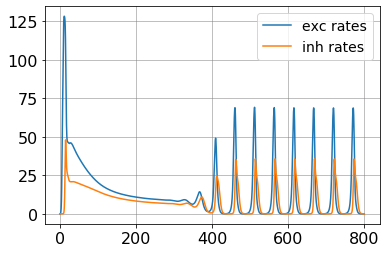

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

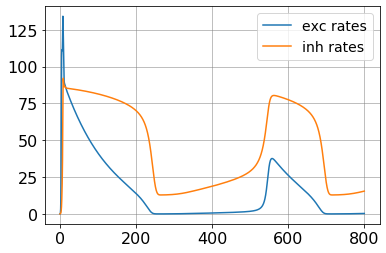

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

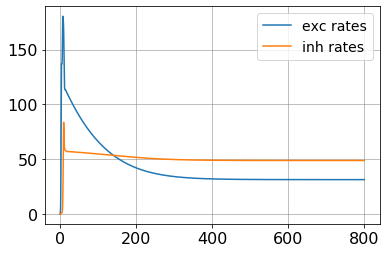

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

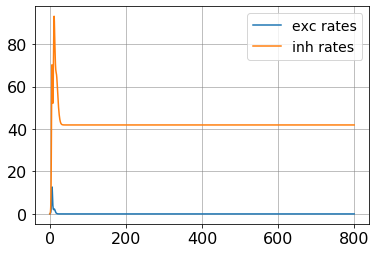

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [8]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl    

def gettranstimeatmax(target, n_dur, mintranstime, maxtranstime):
    max_ind = np.argmax(target[int(mintranstime*n_dur):int(maxtranstime*n_dur)])
    return ( max_ind + int(mintranstime*n_dur) ) / n_dur

In [9]:
dur = 600
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

set_params_fast()
setinit(fast_osc_init)

aln.run(control = aln.getZeroControl())
fast_rates = np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] )

# set slow oscillation as target
target = aln.getZeroTarget()
target[0,0,:] = fast_rates[0,:]
target[0,1,:] = fast_rates[1,:]

In [10]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 200

set_params_up()
initVars = up_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = np.zeros((21))
trans_t = gettranstimeatmax(target[0,0,:], n_dur, 0.4, 0.5)
trans_time_array[:] = trans_t

sheet = "F_a_"

## 1

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  124107.8384447028
RUN  1 , total integrated cost =  25835.973238821472
RUN  2 , total integrated cost =  19688.863072574288
RUN  3 , total integrated cost =  15510.680603193501
RUN  4 , total integrated cost =  13476.705845501447
RUN  5 , total integrated cost =  11420.07397986998
RUN  6 , total integrated cost =  9528.571812336328
RUN  7 , total integrated cost =  8415.431590569406
RUN  8 , total integrated cost =  7578.090691579455
RUN  9 , total integrated cost =  6924.979964514334
RUN  10 , total integrated cost =  6269.810296066817
RUN  11 , total integrated cost =  5831.921039316276
RUN  12 , total integrated cost =  5410.40379939495
RUN  13 , total integrated cost =  5129.601910616892
RUN  14 , total integrated cost =  4833.3199693823435
RUN  15 , total integrated cost =  4630.696544894758
RUN  16 , total integrated cost =  4421.815230450385
RUN  

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  9.274919922746275
RUN  5000 , total integrated cost =  9.274919922746275
Improved over  5000  iterations by  99.99252672511344  percent.
Problem in initial value trasfer:  Vmean_exc -56.68444732772701 -56.661205415567665


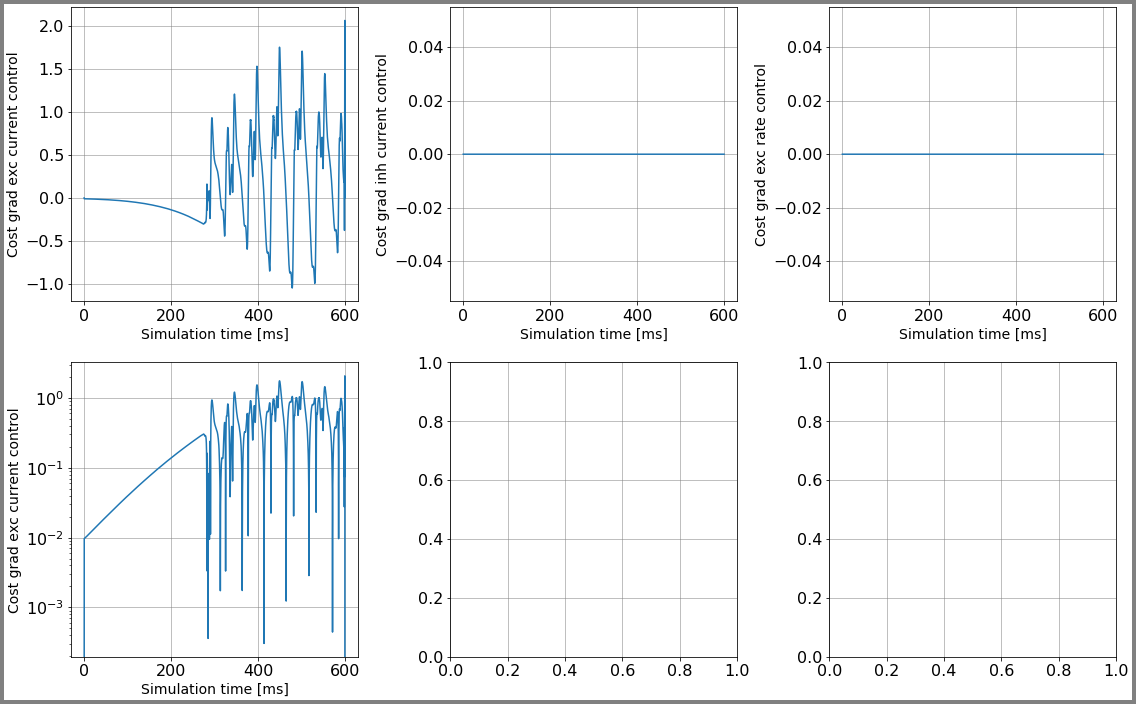

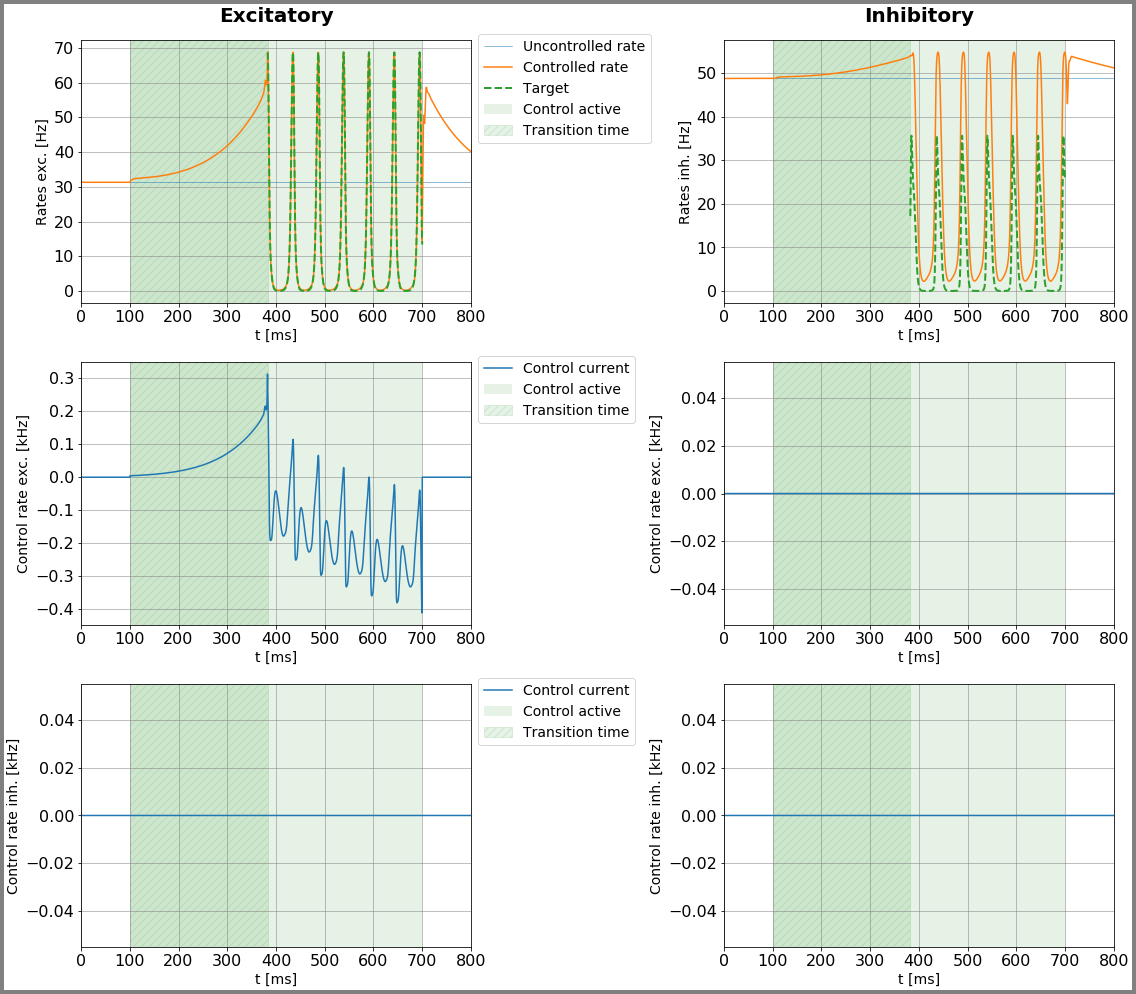

In [11]:
case_ind = 1
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  124107.8384447028
RUN  1 , total integrated cost =  25835.973290977625
RUN  2 , total integrated cost =  19688.86312763312
RUN  3 , total integrated cost =  15510.680659243644
RUN  4 , total integrated cost =  13476.705905757031
RUN  5 , total integrated cost =  11420.074044408619
RUN  6 , total integrated cost =  9528.571882373708
RUN  7 , total integrated cost =  8415.431666813663
RUN  8 , total integrated cost =  7578.090765350613
RUN  9 , total integrated cost =  6924.980039408595
RUN  10 , total integrated cost =  6269.8103736964
RUN  11 , total integrated cost =  5831.921113820439
RUN  12 , total integrated cost =  5410.403877701834
RUN  13 , total integrated cost =  5129.601988205482
RUN  14 , total integrated cost =  4833.320049936518
RUN  15 , total integrated cost =  4630.696625656998
RUN  16 , total integrated cost =  4421.815311399442
RUN  17 , total integrated cost =  4263.0074234078775

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  10.997753925668478
RUN  5000 , total integrated cost =  10.997753925668478
Improved over  5000  iterations by  99.99113855010006  percent.
Problem in initial value trasfer:  Vmean_exc -56.68216761611234 -56.65975147991176


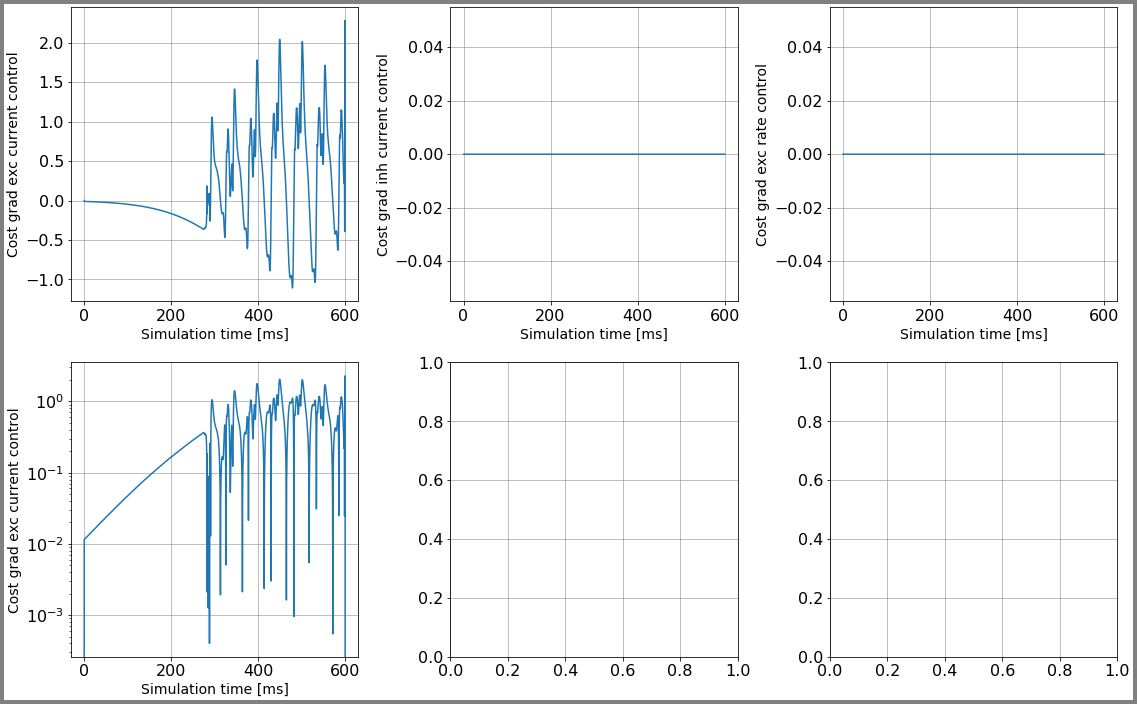

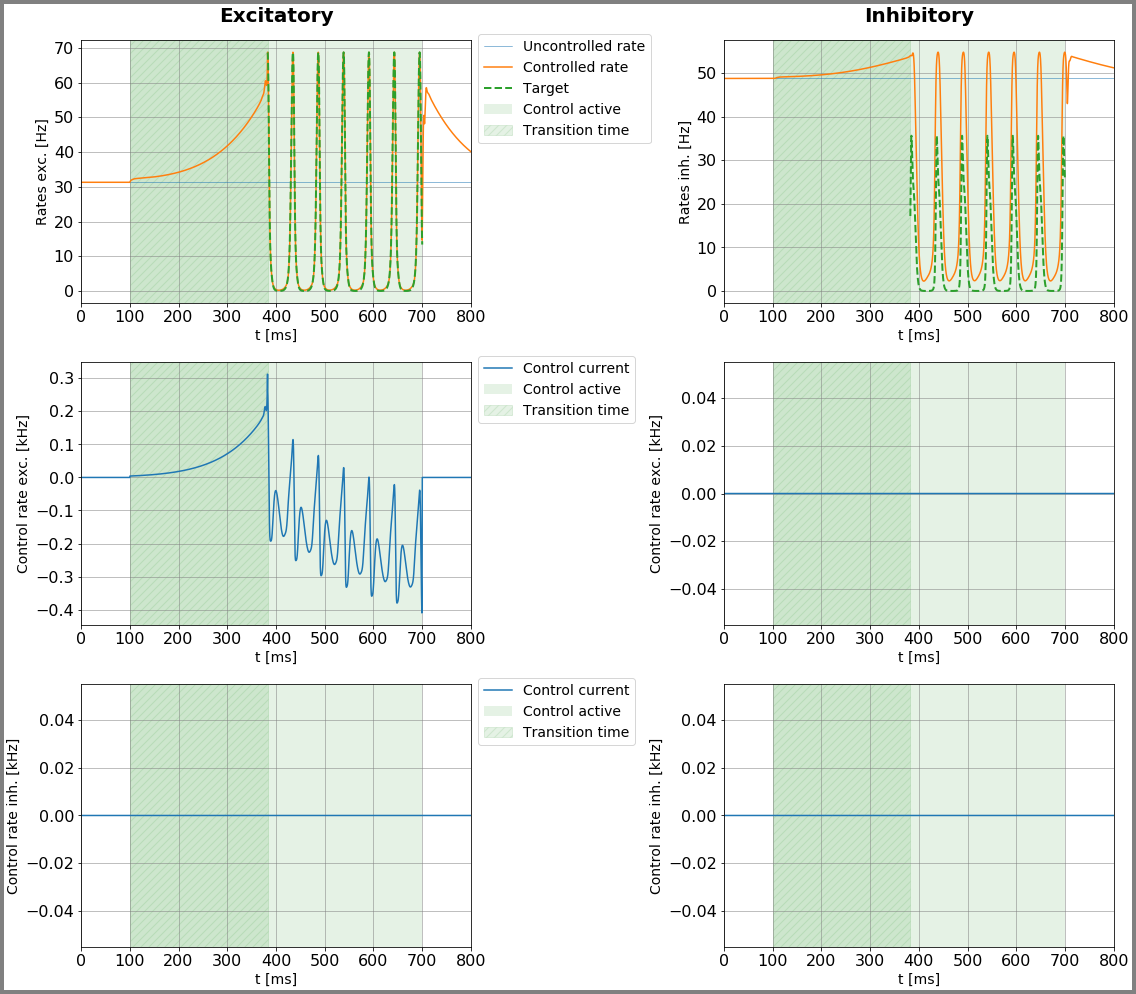

In [12]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 1
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e0, 1e0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 3

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  124107.8384447028
RUN  1 , total integrated cost =  106151.9419096242
RUN  2 , total integrated cost =  105480.6403171676
RUN  3 , total integrated cost =  105475.572805246
RUN  4 , total integrated cost =  105472.92672871702
RUN  5 , total integrated cost =  105472.0297050588
RUN  6 , total integrated cost =  105471.34222768743
RUN  7 , total integrated cost =  105471.25714028884
RUN  8 , total integrated cost =  105471.25695312124
RUN  9 , total integrated cost =  105471.25684105711
RUN  10 , total integrated cost =  105471.25681174257
RUN  11 , total integrated cost =  105471.25676600724
RUN  12 , total integrated cost =  105471.25675330253
RUN  13 , total integrated cost =  105471.25674894157
RUN  14 , total integrated cost =  105471.25673652334
RUN  15 , total integrated cost =  105471.25673532957
RUN  16 , total integrated cost =  105471.2567353106

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  105471.25673530954
Control only changes marginally.
RUN  18 , total integrated cost =  105471.25673530954
Improved over  18  iterations by  15.0164421062711  percent.
Problem in initial value trasfer:  sigmae_f 1.505434316781054 1.5047267950187082
Problem in initial value trasfer:  Vmean_exc -56.65555476850156 -56.6545962877168
Problem in initial value trasfer:  Vmean_exc -56.660691597324515 -56.661356549748184


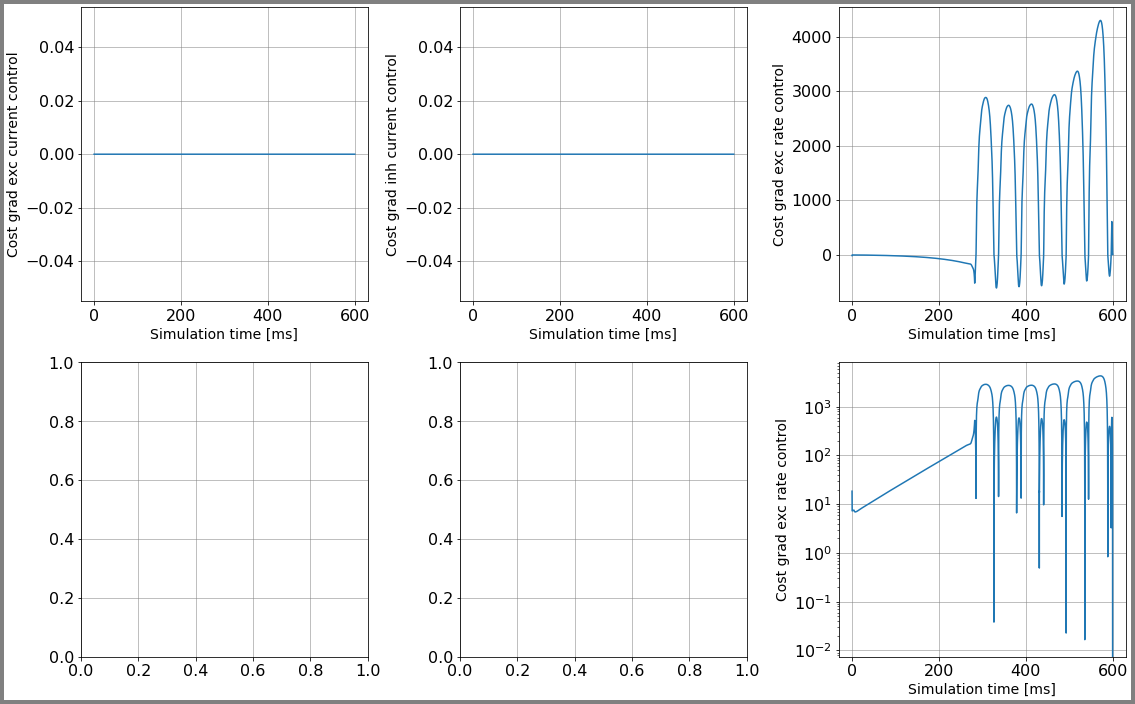

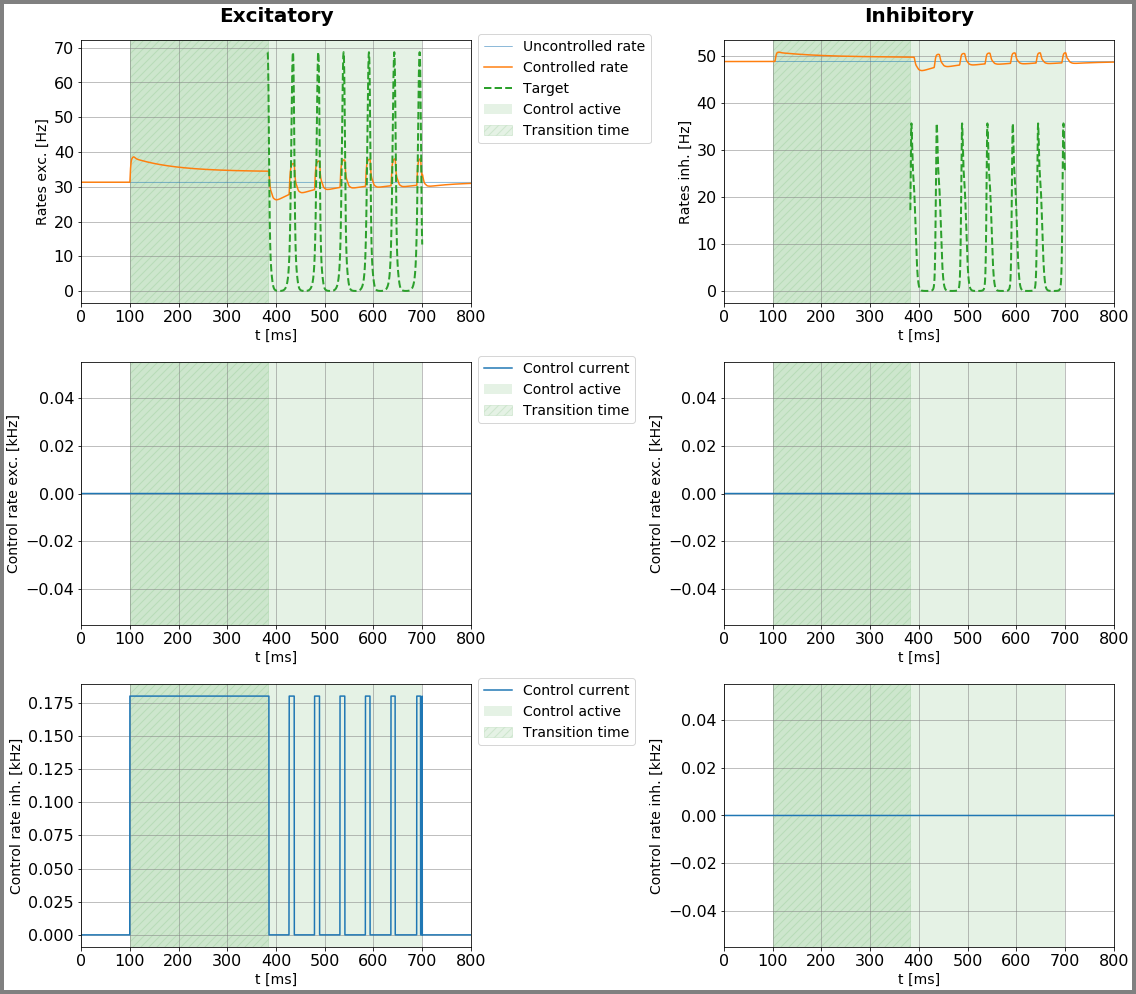

In [13]:
case_ind = 3
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  124107.8384447028
RUN  1 , total integrated cost =  106152.0333132458
RUN  2 , total integrated cost =  105480.72943665308
RUN  3 , total integrated cost =  105475.66184063925
RUN  4 , total integrated cost =  105473.01546373773
RUN  5 , total integrated cost =  105472.11848658243
RUN  6 , total integrated cost =  105471.43106488507
RUN  7 , total integrated cost =  105471.34598668039
RUN  8 , total integrated cost =  105471.3457918265
RUN  9 , total integrated cost =  105471.3456787396
RUN  10 , total integrated cost =  105471.3456487412
RUN  11 , total integrated cost =  105471.34560213529
RUN  12 , total integrated cost =  105471.34558926742
RUN  13 , total integrated cost =  105471.34558477048
RUN  14 , total integrated cost =  105471.34557239799
RUN  15 , total integrated cost =  105471.34557128679
RUN  16 , total integrated cost =  105471.34557124376
RUN  17 , total integrated cost =  105471.3

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  21 , total integrated cost =  105471.34557123962
Improved over  21  iterations by  15.01637052664229  percent.
Problem in initial value trasfer:  sigmae_f 1.505434316781054 1.5047267950187082
Problem in initial value trasfer:  Vmean_exc -56.65555476850156 -56.6545962877168
Problem in initial value trasfer:  Vmean_exc -56.66069160490558 -56.66135655746314


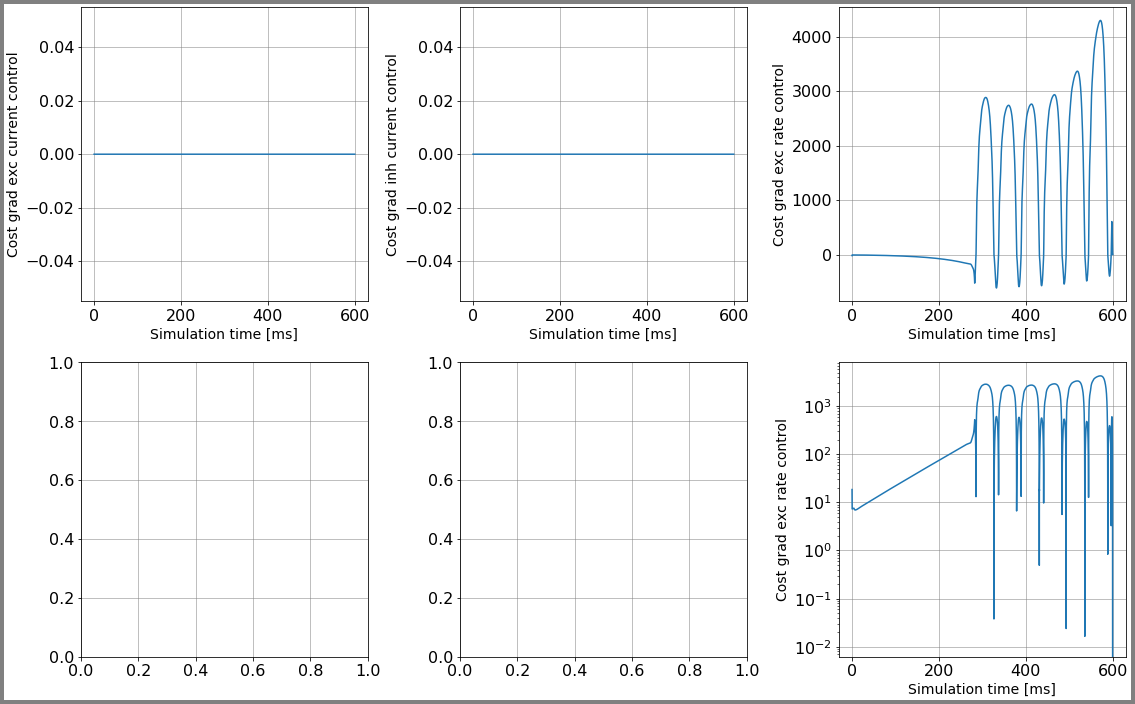

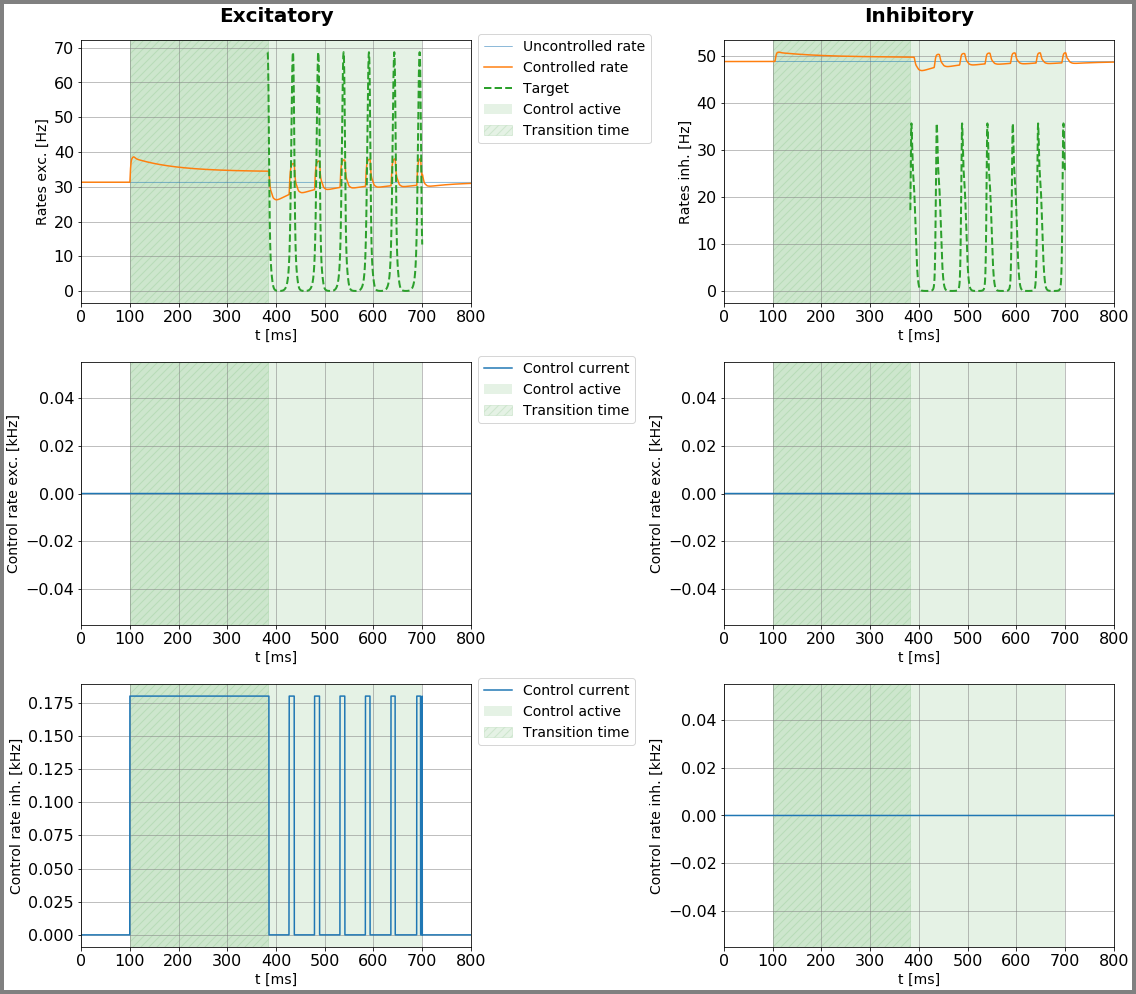

In [14]:
case_ind = 3
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-2, 1e-2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 5

set cost params
control input:  [2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  297723.18473022693
RUN  1 , total integrated cost =  291727.15522246883
RUN  2 , total integrated cost =  291699.86491606577
RUN  3 , total integrated cost =  291693.59703017876
RUN  4 , total integrated cost =  291692.26377557666
RUN  5 , total integrated cost =  291691.9305200311
RUN  6 , total integrated cost =  291691.7940213615


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  291691.7940213615
Control only changes marginally.
RUN  7 , total integrated cost =  291691.7940213615
Improved over  7  iterations in  12.4770374  seconds by  2.0258384359050154  percent.
Problem in initial value trasfer:  sigmae_f 1.505434316781054 1.5047267950187082
Problem in initial value trasfer:  Vmean_exc -56.65555476850156 -56.6545962877168
Problem in initial value trasfer:  Vmean_exc -56.655334534443206 -56.655292846568486


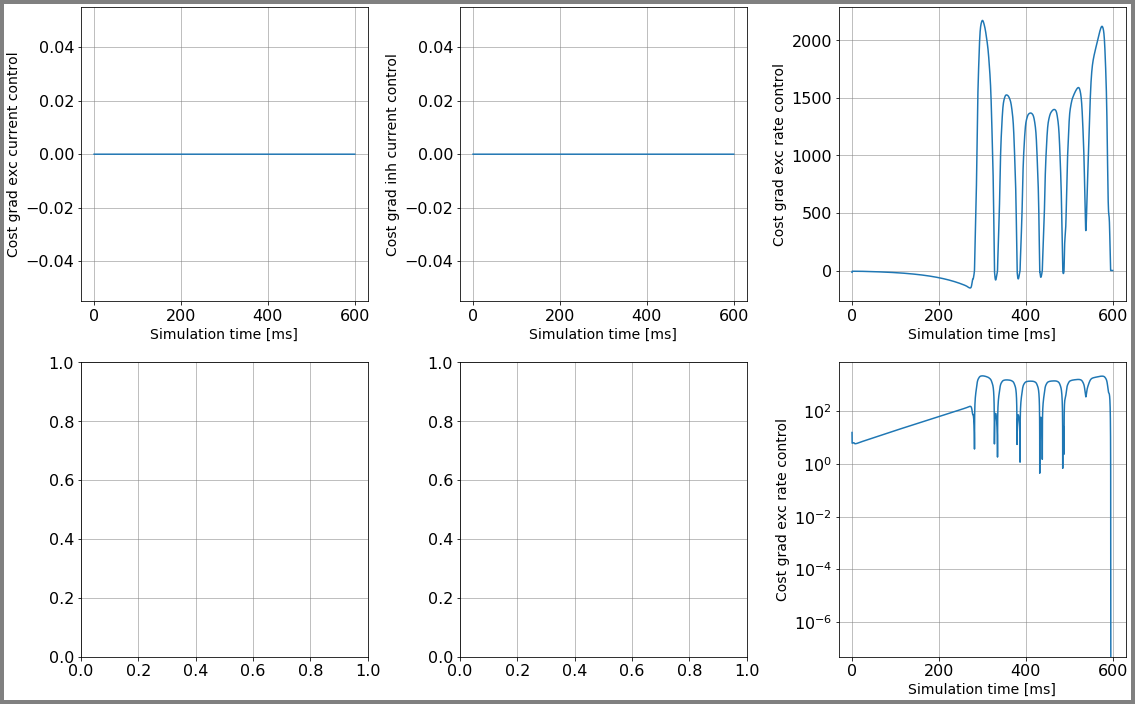

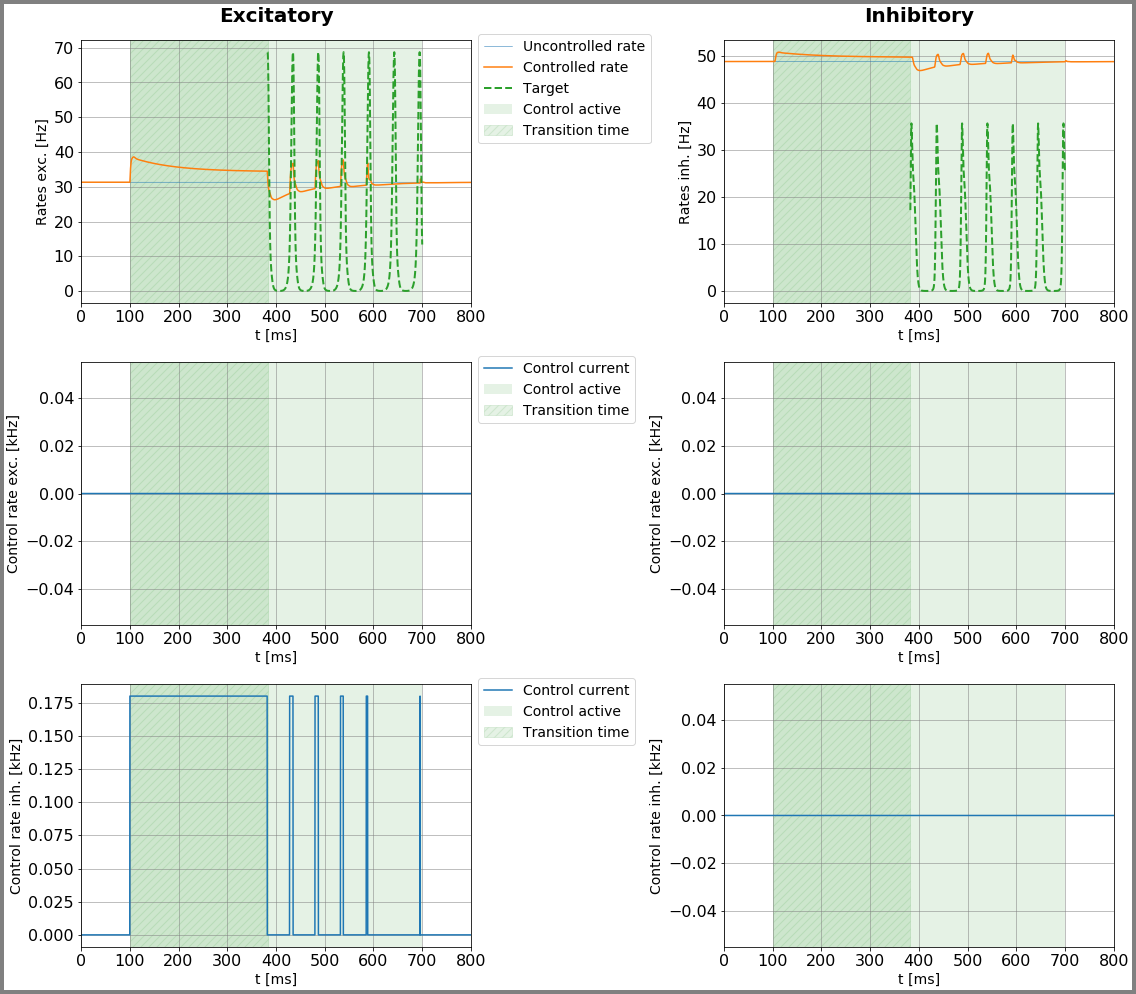

In [11]:
# A.4.a)

case_ind = 5
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None
max_it = 500

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  298517.1298234114
RUN  1 , total integrated cost =  295502.724080577
RUN  2 , total integrated cost =  295481.61140317045
RUN  3 , total integrated cost =  295478.7648850037
RUN  4 , total integrated cost =  295478.27197233884
RUN  5 , total integrated cost =  295478.1782161529
RUN  6 , total integrated cost =  295478.1590378384
RUN  7 , total integrated cost =  295478.15539738256
RUN  8 , total integrated cost =  295478.1544419452
RUN  9 , total integrated cost =  295478.15430945007
RUN  10 , total integrated cost =  295478.154218178
RUN  11 , total integrated cost =  295478.15421741025
RUN  12 , total integrated cost =  295478.1542174091
RUN  13 , total integrated cost =  295478.154217409
RUN  14 , total integrated cost =  295478.15421740885
RUN  15 , total integrated cost =  295478.15421740885


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  15 , total integrated cost =  295478.15421740885
Improved over  15  iterations in  1.9266896999999972  seconds by  1.0180238594013957  percent.
Problem in initial value trasfer:  sigmae_f 1.505434316781054 1.5052878700085384
Problem in initial value trasfer:  Vmean_exc -56.65555476850156 -56.655356375168914
Problem in initial value trasfer:  Vmean_exc -56.655278151117066 -56.65527856575477


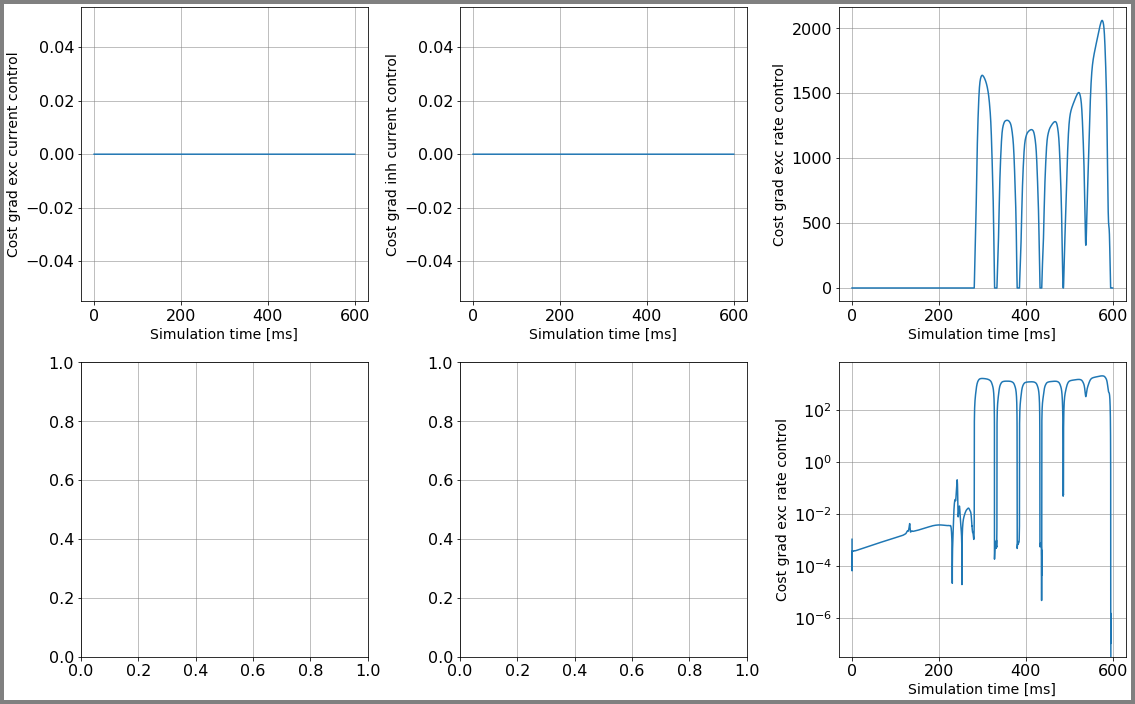

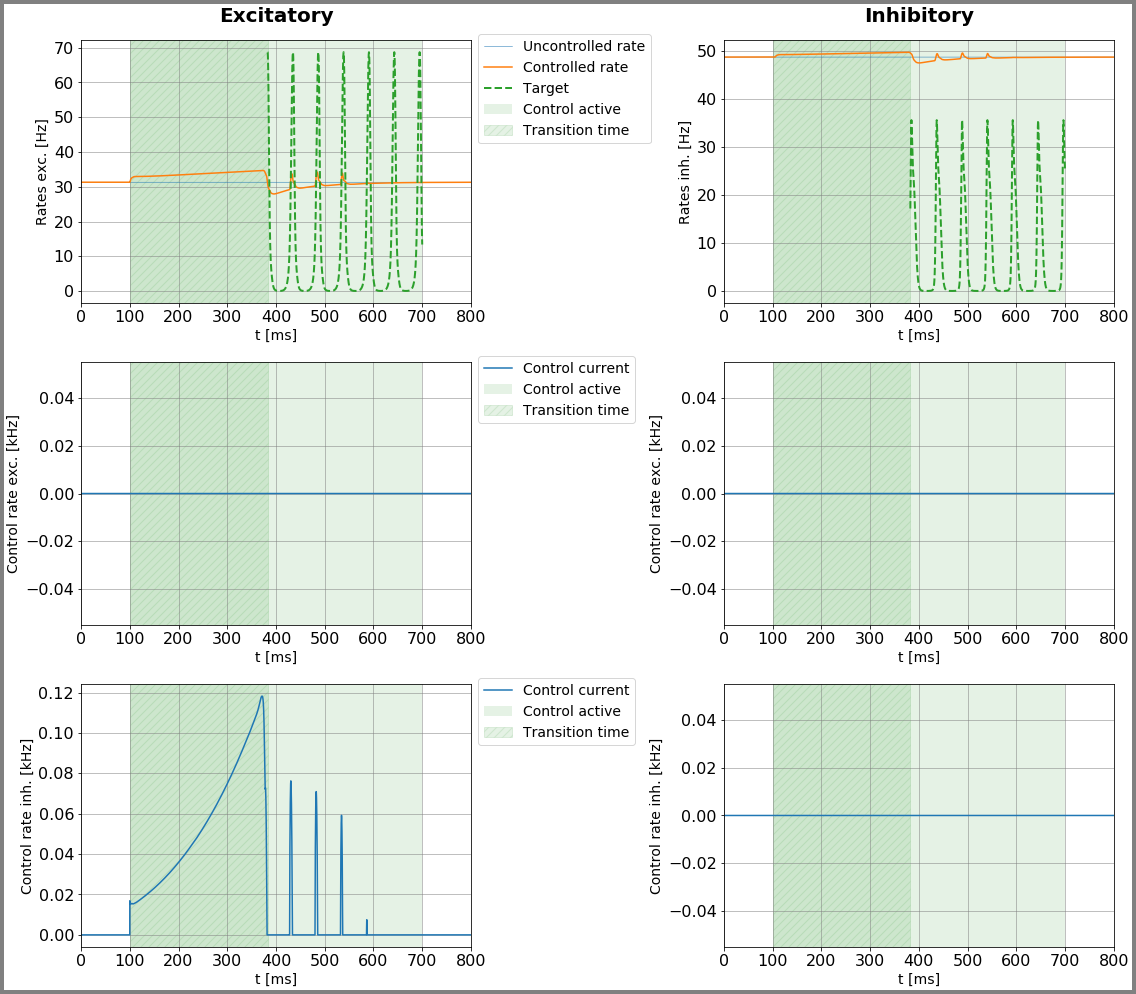

In [13]:
case_ind = 5
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e3, 1e3)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 7

In [ ]:
# A.6.a)
case_ind = 7
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 7
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-5, 1e-5)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 9

In [ ]:
# A.8.a)
case_ind = 9
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 9
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 11

In [ ]:
# A.10.a)
case_ind = 11
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 11
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 13

set cost params
control input:  [0, 1, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  297723.18473022693
RUN  1 , total integrated cost =  20172.054480336275
 max iteration reached, step size =  7.820637090558988e-148
 max iteration reached, step size =  7.820637090558988e-148
 max iteration reached, step size =  7.820637090558988e-148
 max iteration reached, step size =  4.773338067968132e-152
 max iteration reached, step size =  7.820637090558988e-148
RUN  2 , total integrated cost =  20172.054480336275
RUN  2 , total integrated cost =  20172.054480336275
Improved over  2  iterations in  7.170628299999976  seconds by  93.22456042561328  percent.


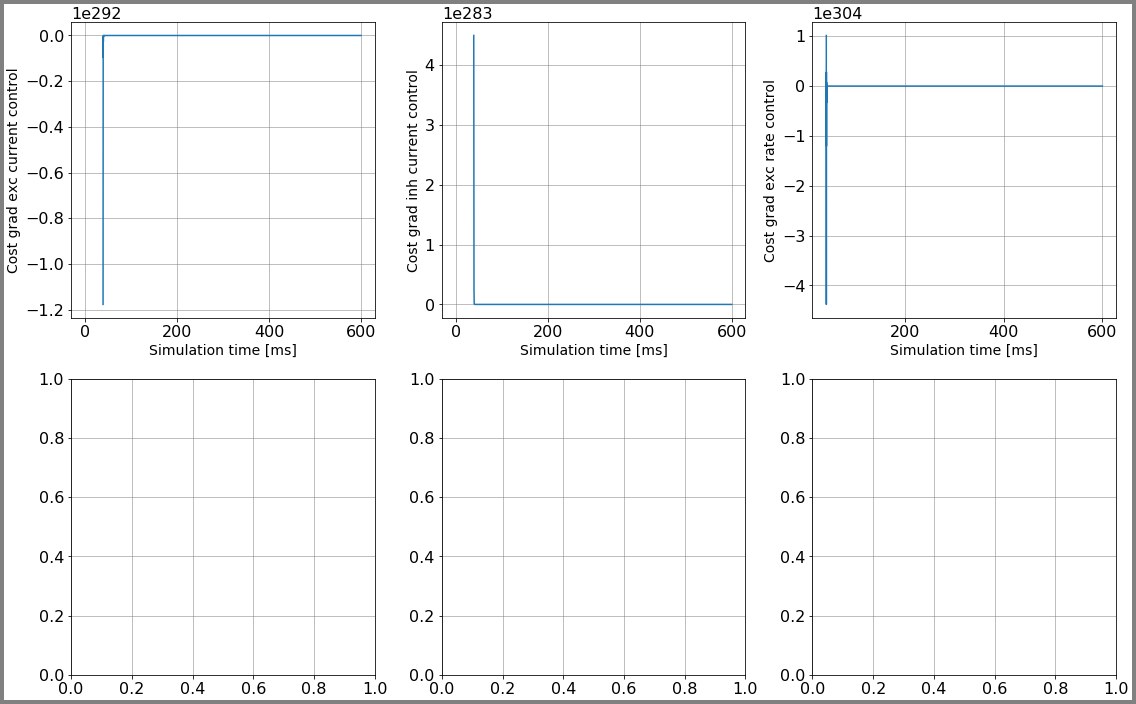

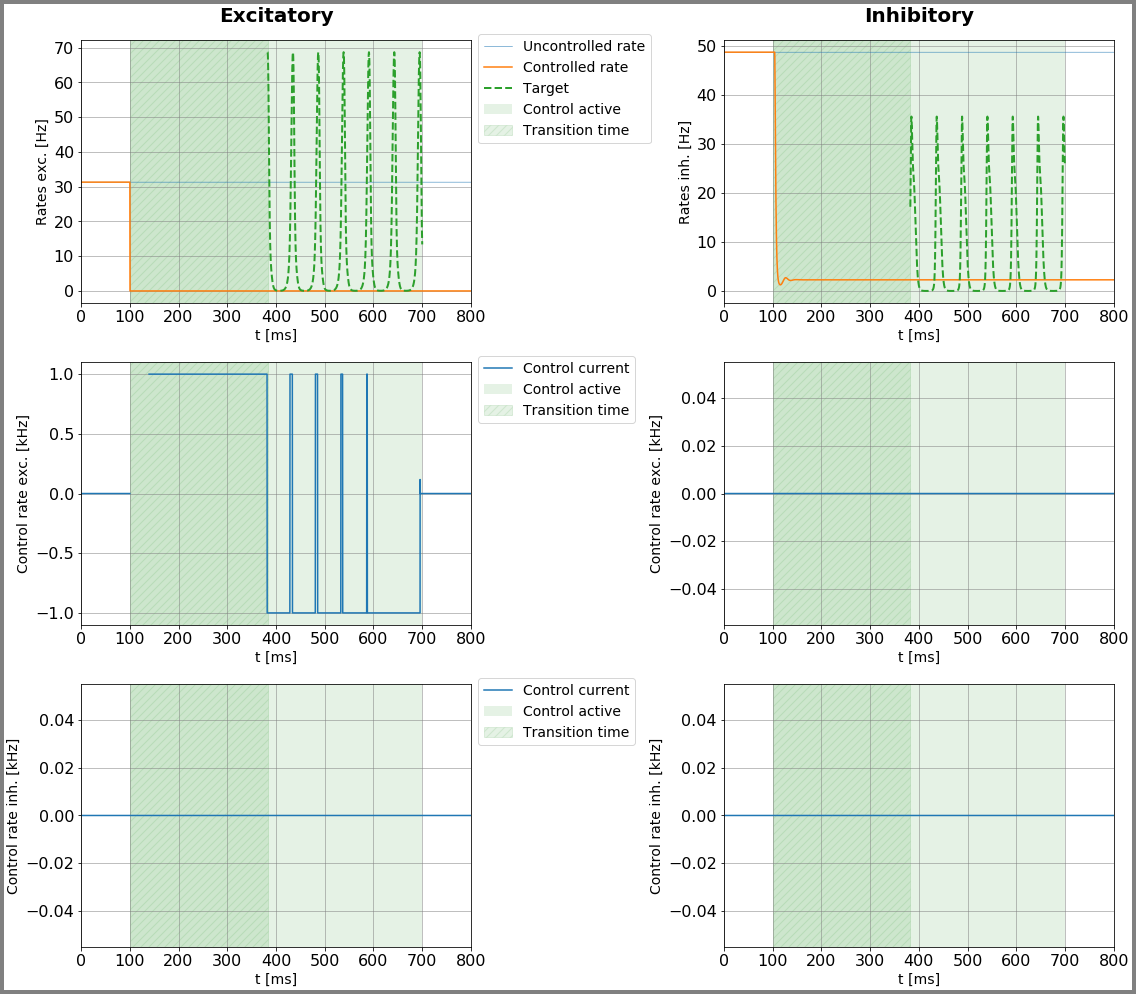

In [15]:
# A.12.a)
case_ind = 13
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None
max_it = 2

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24063.958487446413


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  24063.958487446413
Control only changes marginally.
RUN  1 , total integrated cost =  24063.958487446413
Improved over  1  iterations in  1.1302656000000297  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.505434316781054 1.5052422095677305
Problem in initial value trasfer:  Vmean_exc -56.65555476850156 -56.65529451904446
Problem in initial value trasfer:  Vmean_exc -56.711127277621024 -56.71112875657849


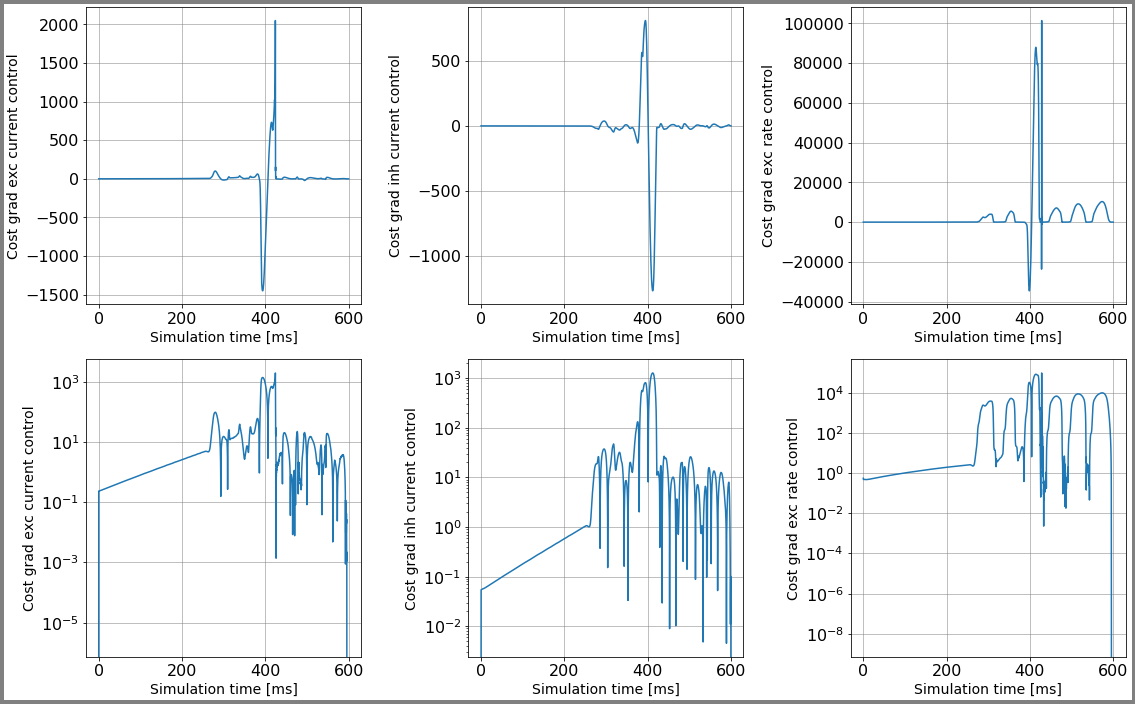

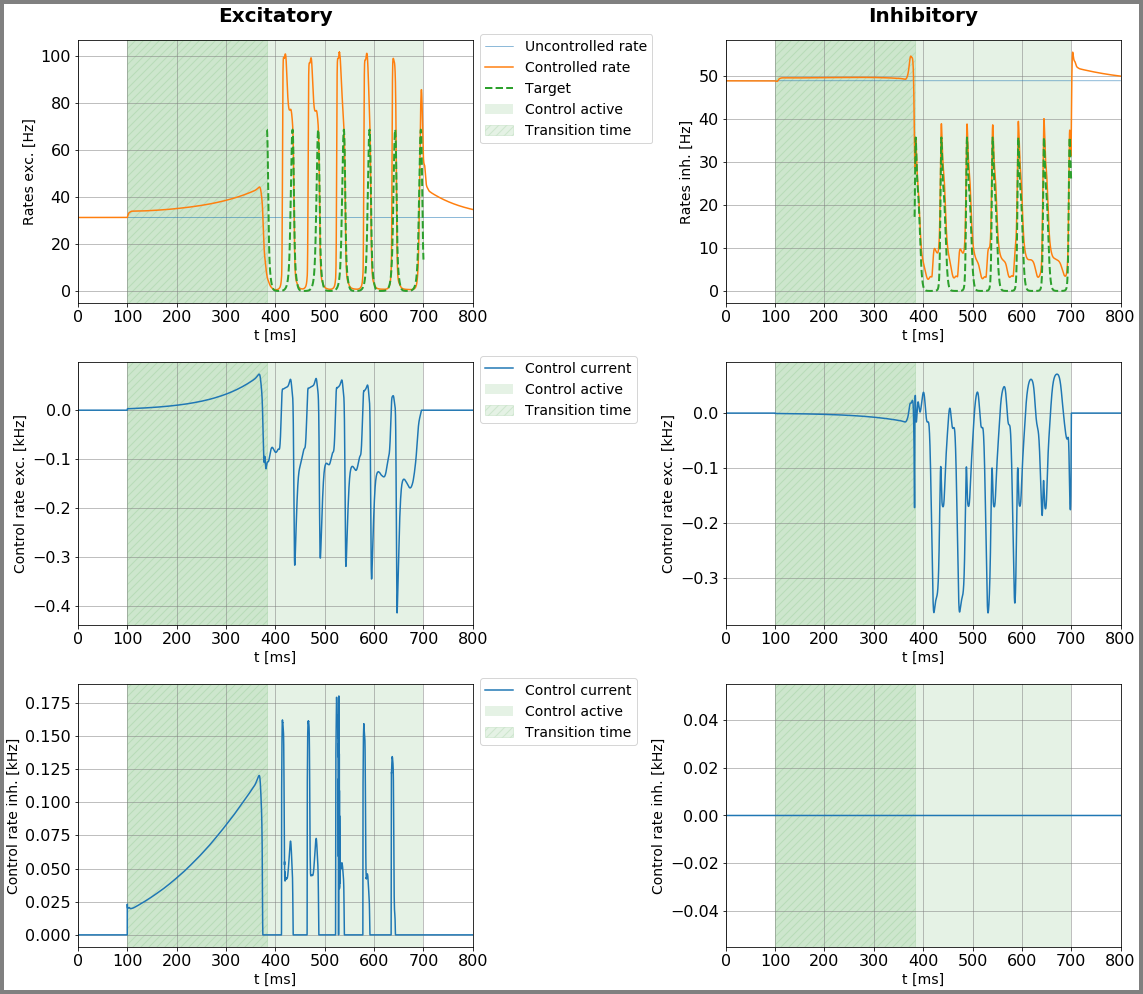

In [20]:
case_ind = 13
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 200

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )